# SkinLens AI

# Notebook 03

## Data Cleaning & Feature Engineering

---

### Objectives

- Load metadata
- Check data quality
- Handle missing values
- Remove unnecessary columns
- Create new features
- Encode categorical variables
- Scale numerical features
- Save processed metadata

This notebook prepares the metadata for PyTorch model training.

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Dataset Paths

In [2]:
DATA_DIR = Path("/kaggle/input/competitions/isic-2024-challenge")

TRAIN_METADATA = DATA_DIR / "train-metadata.csv"

TRAIN_IMAGES = DATA_DIR / "train-image" / "image"

OUTPUT_DIR = Path("/kaggle/working/data/processed")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Metadata :", TRAIN_METADATA)
print("Images   :", TRAIN_IMAGES)
print("Output   :", OUTPUT_DIR)

Metadata : /kaggle/input/competitions/isic-2024-challenge/train-metadata.csv
Images   : /kaggle/input/competitions/isic-2024-challenge/train-image/image
Output   : /kaggle/working/data/processed


In [3]:
print(TRAIN_METADATA.exists())
print(TRAIN_IMAGES.exists())

True
True


# Load Metadata

In [4]:
df = pd.read_csv(TRAIN_METADATA)

print(df.shape)

(401059, 55)


In [5]:
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401059 entries, 0 to 401058
Data columns (total 55 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   isic_id                       401059 non-null  object 
 1   target                        401059 non-null  int64  
 2   patient_id                    401059 non-null  object 
 3   age_approx                    398261 non-null  float64
 4   sex                           389542 non-null  object 
 5   anatom_site_general           395303 non-null  object 
 6   clin_size_long_diam_mm        401059 non-null  float64
 7   image_type                    401059 non-null  object 
 8   tbp_tile_type                 401059 non-null  object 
 9   tbp_lv_A                      401059 non-null  float64
 10  tbp_lv_Aext                   401059 non-null  float64
 11  tbp_lv_B                      401059 non-null  float64
 12  tbp_lv_Bext                   401059 non-nul

# Data Quality Check

In [7]:
quality = {

    "Rows": len(df),

    "Columns": len(df.columns),

    "Duplicate Rows": df.duplicated().sum(),

    "Duplicate ISIC IDs": df["isic_id"].duplicated().sum(),

    "Duplicate Patients": df["patient_id"].duplicated().sum()

}

pd.DataFrame(

quality.items(),

columns=["Metric","Value"]

)

,Metric,Value
0,Rows,401059
1,Columns,55
2,Duplicate Rows,0
3,Duplicate ISIC IDs,0
4,Duplicate Patients,400017


In [8]:
missing = (

    df.isnull()

    .sum()

    .sort_values(

        ascending=False

    )

)

missing.head(20)

iddx_5                 401058
mel_mitotic_index      401006
mel_thick_mm           400996
iddx_4                 400508
iddx_3                 399994
iddx_2                 399991
lesion_id              379001
sex                     11517
anatom_site_general      5756
age_approx               2798
image_type                  0
tbp_lv_B                    0
tbp_lv_Bext                 0
tbp_lv_C                    0
tbp_lv_Cext                 0
tbp_lv_H                    0
tbp_tile_type               0
tbp_lv_A                    0
tbp_lv_Aext                 0
patient_id                  0
dtype: int64

In [9]:
missing_percent = (

    df.isnull()

    .mean()

    *100

).sort_values(

ascending=False

)

missing_percent.head(20)

iddx_5                 99.999751
mel_mitotic_index      99.986785
mel_thick_mm           99.984292
iddx_4                 99.862614
iddx_3                 99.734453
iddx_2                 99.733705
lesion_id              94.500061
sex                     2.871647
anatom_site_general     1.435200
age_approx              0.697653
image_type              0.000000
tbp_lv_B                0.000000
tbp_lv_Bext             0.000000
tbp_lv_C                0.000000
tbp_lv_Cext             0.000000
tbp_lv_H                0.000000
tbp_tile_type           0.000000
tbp_lv_A                0.000000
tbp_lv_Aext             0.000000
patient_id              0.000000
dtype: float64

In [10]:
missing_df = pd.DataFrame({

    "Missing":missing,

    "Percentage":missing_percent

})

missing_df.head(20)

,Missing,Percentage
iddx_5,401058,99.999751
mel_mitotic_index,401006,99.986785
mel_thick_mm,400996,99.984292
iddx_4,400508,99.862614
iddx_3,399994,99.734453
iddx_2,399991,99.733705
lesion_id,379001,94.500061
sex,11517,2.871647
anatom_site_general,5756,1.435200
age_approx,2798,0.697653


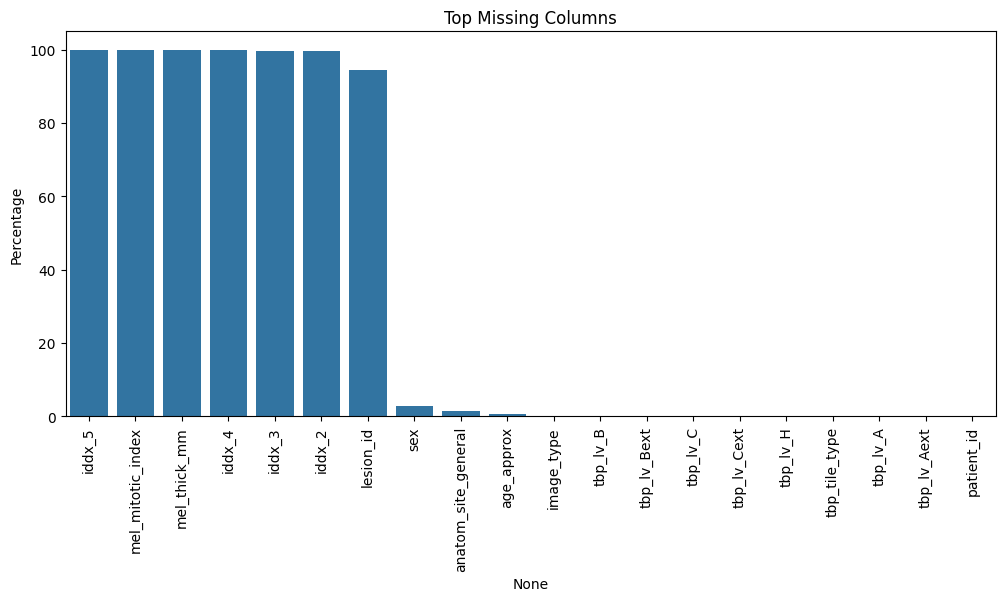

In [11]:
plt.figure(figsize=(12,5))

sns.barplot(

x=missing_df.head(20).index,

y=missing_df.head(20)["Percentage"]

)

plt.xticks(rotation=90)

plt.title("Top Missing Columns")

plt.show()

# Numerical & Categorical Columns

In [12]:
numerical_cols = df.select_dtypes(

include=["int64","float64"]

).columns.tolist()

categorical_cols = df.select_dtypes(

include="object"

).columns.tolist()

print("Numerical :",len(numerical_cols))

print("Categorical :",len(categorical_cols))

Numerical : 37
Categorical : 18


In [13]:
print(numerical_cols)

['target', 'age_approx', 'clin_size_long_diam_mm', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidence']


In [14]:
print(categorical_cols)

['isic_id', 'patient_id', 'sex', 'anatom_site_general', 'image_type', 'tbp_tile_type', 'tbp_lv_location', 'tbp_lv_location_simple', 'attribution', 'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index']


# Missing Value Treatment

In [15]:
for col in numerical_cols:

    if df[col].isnull().sum()>0:

        df[col].fillna(

            df[col].median(),

            inplace=True

        )

In [16]:
for col in categorical_cols:

    if df[col].isnull().sum()>0:

        df[col].fillna(

            df[col].mode()[0],

            inplace=True

        )

In [17]:
print(

df.isnull().sum().sum()

)

0


# Duplicate Verification

In [18]:
print(

"Duplicate Rows :",

df.duplicated().sum()

)

Duplicate Rows : 0


In [19]:
print(

"Duplicate Images :",

df["isic_id"].duplicated().sum()

)

Duplicate Images : 0


# Remove Unnecessary Columns

In [20]:
drop_cols = []

for col in df.columns:

    if df[col].nunique()==1:

        drop_cols.append(col)

drop_cols

['image_type', 'iddx_5']

In [21]:
df.drop(

columns=drop_cols,

inplace=True,

errors="ignore"

)

print(df.shape)

(401059, 53)


# Data Cleaning Completed

✔ Missing Values Filled

✔ Duplicate Check Completed

✔ Constant Columns Removed

Ready for Feature Engineering.

# Feature Engineering

In this section we will create new metadata features that can improve
model performance and make the dataset easier to use during training.

In [22]:
# Backup cleaned dataframe

df_processed = df.copy()

print(df_processed.shape)

(401059, 53)


# Create Image Path

In [23]:
if "isic_id" in df_processed.columns:

    df_processed["image_path"] = df_processed["isic_id"].apply(
        lambda x: str(TRAIN_IMAGES / f"{x}.jpg")
    )

df_processed[["isic_id", "image_path"]].head()

,isic_id,image_path
0,ISIC_0015670,/kaggle/input/competitions/isic-2024-challenge...
1,ISIC_0015845,/kaggle/input/competitions/isic-2024-challenge...
2,ISIC_0015864,/kaggle/input/competitions/isic-2024-challenge...
3,ISIC_0015902,/kaggle/input/competitions/isic-2024-challenge...
4,ISIC_0024200,/kaggle/input/competitions/isic-2024-challenge...


# Patient Image Count

In [24]:
patient_counts = df_processed.groupby(
    "patient_id"
)["patient_id"].transform("count")

df_processed["patient_image_count"] = patient_counts

df_processed[[
    "patient_id",
    "patient_image_count"
]].head()

,patient_id,patient_image_count
0,IP_1235828,510
1,IP_8170065,113
2,IP_6724798,1859
3,IP_4111386,541
4,IP_8313778,440


# Age Feature Engineering

In [25]:
if "age_approx" in df_processed.columns:

    bins = [0,20,40,60,80,120]

    labels = [

        "0-20",

        "21-40",

        "41-60",

        "61-80",

        "80+"

    ]

    df_processed["age_group"] = pd.cut(

        df_processed["age_approx"],

        bins=bins,

        labels=labels,

        include_lowest=True

    )

df_processed[[
    "age_approx",
    "age_group"
]].head()

,age_approx,age_group
0,60.0,41-60
1,60.0,41-60
2,60.0,41-60
3,65.0,61-80
4,55.0,41-60


# Normalize Sex Column

In [26]:
if "sex" in df_processed.columns:

    df_processed["sex"] = (

        df_processed["sex"]

        .astype(str)

        .str.lower()

        .str.strip()

    )

    df_processed["sex"] = (

        df_processed["sex"]

        .replace({

            "male":"Male",

            "female":"Female",

            "nan":"Unknown",

            "none":"Unknown"

        })

    )

df_processed["sex"].value_counts()

sex
Male      277063
Female    123996
Name: count, dtype: int64

# Anatomical Site Cleaning

In [27]:
if "anatom_site_general" in df_processed.columns:

    df_processed["anatom_site_general"] = (

        df_processed["anatom_site_general"]

        .astype(str)

        .str.lower()

        .str.strip()

    )

df_processed["anatom_site_general"].value_counts().head()

anatom_site_general
posterior torso    127658
lower extremity    103028
anterior torso      87770
upper extremity     70557
head/neck           12046
Name: count, dtype: int64

# Left / Right Body Side

In [28]:
if "tbp_lv_location" in df_processed.columns:

    def get_side(x):

        x = str(x).lower()

        if "left" in x:
            return "Left"

        elif "right" in x:
            return "Right"

        else:
            return "Unknown"

    df_processed["body_side"] = (

        df_processed["tbp_lv_location"]

        .apply(get_side)

    )

df_processed["body_side"].value_counts()

body_side
Unknown    227474
Left        89423
Right       84162
Name: count, dtype: int64

# Lesion Size Category

In [29]:
candidate_cols = [

    "clin_size_long_diam_mm",

    "tbp_lv_minorAxisMM"

]

size_col = None

for col in candidate_cols:

    if col in df_processed.columns:

        size_col = col

        break

if size_col:

    df_processed["lesion_size_category"] = pd.qcut(

        df_processed[size_col],

        q=3,

        labels=[

            "Small",

            "Medium",

            "Large"

        ]

    )

    display(

        df_processed[[

            size_col,

            "lesion_size_category"

        ]].head()

    )
else:

    print("No lesion size column found.")

,clin_size_long_diam_mm,lesion_size_category
0,3.04,Medium
1,1.10,Small
2,3.40,Medium
3,3.22,Medium
4,2.73,Small


# Patient Malignancy Count

In [30]:
patient_positive = (

    df_processed.groupby("patient_id")["target"]

    .transform("sum")

)

df_processed["patient_positive_cases"] = patient_positive

df_processed[[
    "patient_id",
    "patient_positive_cases"
]].head()

,patient_id,patient_positive_cases
0,IP_1235828,0
1,IP_8170065,1
2,IP_6724798,1
3,IP_4111386,0
4,IP_8313778,2


# Target Data Type

In [31]:
df_processed["target"] = (

    df_processed["target"]

    .astype(np.int8)

)

df_processed["target"].dtype

dtype('int8')

# Engineered Features

In [32]:
new_features = [

    "image_path",

    "patient_image_count",

    "age_group",

    "body_side",

    "lesion_size_category",

    "patient_positive_cases"

]

available = [

    f

    for f in new_features

    if f in df_processed.columns

]

available

['image_path',
 'patient_image_count',
 'age_group',
 'body_side',
 'lesion_size_category',
 'patient_positive_cases']

# Preview Engineered Dataset

In [33]:
df_processed.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,...,iddx_4,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence,image_path,patient_image_count,age_group,body_side,lesion_size_category,patient_positive_cases
0,ISIC_0015670,0,IP_1235828,60.0,Male,lower extremity,3.04,3D: white,20.244422,16.261975,...,"Nevus, Atypical, Dysplastic, or Clark",0/mm^2,0.4,97.517282,/kaggle/input/competitions/isic-2024-challenge...,510,41-60,Right,Medium,0
1,ISIC_0015845,0,IP_8170065,60.0,Male,head/neck,1.10,3D: white,31.712570,25.364740,...,"Nevus, Atypical, Dysplastic, or Clark",0/mm^2,0.4,3.141455,/kaggle/input/competitions/isic-2024-challenge...,113,41-60,Unknown,Small,1
2,ISIC_0015864,0,IP_6724798,60.0,Male,posterior torso,3.40,3D: XP,22.575830,17.128170,...,"Nevus, Atypical, Dysplastic, or Clark",0/mm^2,0.4,99.804040,/kaggle/input/competitions/isic-2024-challenge...,1859,41-60,Unknown,Medium,1
3,ISIC_0015902,0,IP_4111386,65.0,Male,anterior torso,3.22,3D: XP,14.242329,12.164757,...,"Nevus, Atypical, Dysplastic, or Clark",0/mm^2,0.4,99.989998,/kaggle/input/competitions/isic-2024-challenge...,541,61-80,Unknown,Medium,0
4,ISIC_0024200,0,IP_8313778,55.0,Male,anterior torso,2.73,3D: white,24.725520,20.057470,...,"Nevus, Atypical, Dysplastic, or Clark",0/mm^2,0.4,70.442510,/kaggle/input/competitions/isic-2024-challenge...,440,41-60,Unknown,Small,2


# Dataset Shape After Feature Engineering

In [34]:
print(

"Original Shape :",df.shape

)

print(

"Processed Shape :",df_processed.shape

)

Original Shape : (401059, 53)
Processed Shape : (401059, 59)


# Missing Values After Engineering

In [35]:
df_processed.isnull().sum().sort_values(
    ascending=False
).head(20)

isic_id                    0
target                     0
patient_id                 0
age_approx                 0
sex                        0
anatom_site_general        0
clin_size_long_diam_mm     0
tbp_tile_type              0
tbp_lv_A                   0
tbp_lv_Aext                0
tbp_lv_B                   0
tbp_lv_Bext                0
tbp_lv_C                   0
tbp_lv_Cext                0
tbp_lv_H                   0
tbp_lv_Hext                0
tbp_lv_L                   0
tbp_lv_Lext                0
tbp_lv_areaMM2             0
tbp_lv_area_perim_ratio    0
dtype: int64

In [36]:
print(

"Remaining Missing Cells :",

df_processed.isnull().sum().sum()

)

Remaining Missing Cells : 0


# Feature Engineering Completed

✔ Image Path Created

✔ Patient Image Count Added

✔ Age Groups Created

✔ Sex Normalized

✔ Anatomical Site Cleaned

✔ Body Side Feature Added

✔ Lesion Size Category Added (if available)

✔ Patient Positive Case Count Added

Ready for Encoding & Scaling

# Categorical Feature Encoding

Convert categorical variables into numerical values
so they can be used by machine learning models.

In [37]:
# Identify categorical columns

categorical_cols = df_processed.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Remove image_path (used only for loading images)

exclude_cols = [
    "image_path",
    "isic_id",
    "patient_id"
]

categorical_cols = [
    c for c in categorical_cols
    if c not in exclude_cols
]

print("Categorical Features")

categorical_cols

Categorical Features


['sex',
 'anatom_site_general',
 'tbp_tile_type',
 'tbp_lv_location',
 'tbp_lv_location_simple',
 'attribution',
 'copyright_license',
 'lesion_id',
 'iddx_full',
 'iddx_1',
 'iddx_2',
 'iddx_3',
 'iddx_4',
 'mel_mitotic_index',
 'age_group',
 'body_side',
 'lesion_size_category']

# Label Encoding

In [38]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

In [39]:
for col in categorical_cols:

    encoder = LabelEncoder()

    df_processed[col] = encoder.fit_transform(
        df_processed[col].astype(str)
    )

    label_encoders[col] = encoder

print("Encoding Completed")

Encoding Completed


In [40]:
df_processed[categorical_cols].head()

,sex,anatom_site_general,tbp_tile_type,tbp_lv_location,tbp_lv_location_simple,attribution,copyright_license,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,mel_mitotic_index,age_group,body_side,lesion_size_category
0,1,2,1,12,4,4,1,0,0,0,3,14,14,0,2,1,1
1,1,1,1,0,0,4,1,14800,0,0,3,14,14,0,2,2,2
2,1,3,0,16,5,4,1,0,0,0,3,14,14,0,2,2,1
3,1,0,0,19,6,0,0,0,0,0,3,14,14,0,3,2,1
4,1,0,1,19,6,4,1,0,0,0,3,14,14,0,2,2,2


# Save Label Encoders

In [41]:
import joblib

encoder_path = OUTPUT_DIR / "label_encoders.pkl"

joblib.dump(
    label_encoders,
    encoder_path
)

print(encoder_path)

/kaggle/working/data/processed/label_encoders.pkl


# Numerical Feature Scaling

In [42]:
numeric_cols = df_processed.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32",
        "int16",
        "int8"
    ]
).columns.tolist()

numeric_cols.remove("target")

numeric_cols

['age_approx',
 'sex',
 'anatom_site_general',
 'clin_size_long_diam_mm',
 'tbp_tile_type',
 'tbp_lv_A',
 'tbp_lv_Aext',
 'tbp_lv_B',
 'tbp_lv_Bext',
 'tbp_lv_C',
 'tbp_lv_Cext',
 'tbp_lv_H',
 'tbp_lv_Hext',
 'tbp_lv_L',
 'tbp_lv_Lext',
 'tbp_lv_areaMM2',
 'tbp_lv_area_perim_ratio',
 'tbp_lv_color_std_mean',
 'tbp_lv_deltaA',
 'tbp_lv_deltaB',
 'tbp_lv_deltaL',
 'tbp_lv_deltaLB',
 'tbp_lv_deltaLBnorm',
 'tbp_lv_eccentricity',
 'tbp_lv_location',
 'tbp_lv_location_simple',
 'tbp_lv_minorAxisMM',
 'tbp_lv_nevi_confidence',
 'tbp_lv_norm_border',
 'tbp_lv_norm_color',
 'tbp_lv_perimeterMM',
 'tbp_lv_radial_color_std_max',
 'tbp_lv_stdL',
 'tbp_lv_stdLExt',
 'tbp_lv_symm_2axis',
 'tbp_lv_symm_2axis_angle',
 'tbp_lv_x',
 'tbp_lv_y',
 'tbp_lv_z',
 'attribution',
 'copyright_license',
 'lesion_id',
 'iddx_full',
 'iddx_1',
 'iddx_2',
 'iddx_3',
 'iddx_4',
 'mel_mitotic_index',
 'mel_thick_mm',
 'tbp_lv_dnn_lesion_confidence',
 'patient_image_count',
 'age_group',
 'body_side',
 'lesion_size_c

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [44]:
df_processed[numeric_cols] = scaler.fit_transform(
    df_processed[numeric_cols]
)

In [45]:
df_processed[numeric_cols].head()

,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,...,iddx_3,iddx_4,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence,patient_image_count,age_group,body_side,lesion_size_category,patient_positive_cases
0,0.145624,0.668982,-0.147384,-0.511069,1.575673,0.067613,0.380443,-0.257500,-0.659882,-0.192995,...,0.019775,0.016926,-0.008334,-0.004082,0.039472,-0.379585,-0.344858,-0.420005,-0.017187,-0.538904
1,0.145624,0.668982,-0.875461,-1.624050,1.575673,2.935019,2.959583,-0.369545,-0.527265,1.126869,...,0.019775,0.016926,-0.008334,-0.004082,-10.451661,-0.617827,-0.344858,0.800173,1.195929,0.326941
2,0.145624,0.668982,0.580693,-0.304536,-0.634649,0.650540,0.625867,1.835454,1.466075,1.644677,...,0.019775,0.016926,-0.008334,-0.004082,0.293675,0.429955,-0.344858,0.800173,-0.017187,0.326941
3,0.514637,0.668982,-1.603538,-0.407803,-0.634649,-1.433104,-0.780446,-1.294561,-1.291919,-1.583639,...,0.019775,0.016926,-0.008334,-0.004082,0.314347,-0.360982,0.999703,0.800173,-0.017187,-0.538904
4,-0.223390,0.668982,-1.603538,-0.688917,1.575673,1.188031,1.455843,-0.344179,-0.268249,0.250792,...,0.019775,0.016926,-0.008334,-0.004082,-2.970251,-0.421593,-0.344858,0.800173,1.195929,1.192786


# Save Standard Scaler

In [46]:
scaler_path = OUTPUT_DIR / "scaler.pkl"

joblib.dump(
    scaler,
    scaler_path
)

print(scaler_path)

/kaggle/working/data/processed/scaler.pkl


# Feature Selection


In [47]:
excluded = [

    "image_path",

    "target"

]

selected_features = [

    c

    for c in df_processed.columns

    if c not in excluded

]

len(selected_features)

57

In [48]:
selected_features[:20]

['isic_id',
 'patient_id',
 'age_approx',
 'sex',
 'anatom_site_general',
 'clin_size_long_diam_mm',
 'tbp_tile_type',
 'tbp_lv_A',
 'tbp_lv_Aext',
 'tbp_lv_B',
 'tbp_lv_Bext',
 'tbp_lv_C',
 'tbp_lv_Cext',
 'tbp_lv_H',
 'tbp_lv_Hext',
 'tbp_lv_L',
 'tbp_lv_Lext',
 'tbp_lv_areaMM2',
 'tbp_lv_area_perim_ratio',
 'tbp_lv_color_std_mean']

# Save Feature List

In [49]:
feature_path = OUTPUT_DIR / "selected_features.pkl"

joblib.dump(

    selected_features,

    feature_path

)

print(feature_path)

/kaggle/working/data/processed/selected_features.pkl


# Save Processed Metadata

In [50]:
processed_csv = OUTPUT_DIR / "processed_train_metadata.csv"

df_processed.to_csv(

    processed_csv,

    index=False

)

print(processed_csv)

/kaggle/working/data/processed/processed_train_metadata.csv


In [51]:
processed_df = pd.read_csv(processed_csv)

processed_df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,...,iddx_4,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence,image_path,patient_image_count,age_group,body_side,lesion_size_category,patient_positive_cases
0,ISIC_0015670,0,IP_1235828,0.145624,0.668982,-0.147384,-0.511069,1.575673,0.067613,0.380443,...,0.016926,-0.008334,-0.004082,0.039472,/kaggle/input/competitions/isic-2024-challenge...,-0.379585,-0.344858,-0.420005,-0.017187,-0.538904
1,ISIC_0015845,0,IP_8170065,0.145624,0.668982,-0.875461,-1.624050,1.575673,2.935019,2.959583,...,0.016926,-0.008334,-0.004082,-10.451661,/kaggle/input/competitions/isic-2024-challenge...,-0.617827,-0.344858,0.800173,1.195929,0.326941
2,ISIC_0015864,0,IP_6724798,0.145624,0.668982,0.580693,-0.304536,-0.634649,0.650540,0.625867,...,0.016926,-0.008334,-0.004082,0.293675,/kaggle/input/competitions/isic-2024-challenge...,0.429955,-0.344858,0.800173,-0.017187,0.326941
3,ISIC_0015902,0,IP_4111386,0.514637,0.668982,-1.603538,-0.407803,-0.634649,-1.433104,-0.780446,...,0.016926,-0.008334,-0.004082,0.314347,/kaggle/input/competitions/isic-2024-challenge...,-0.360982,0.999703,0.800173,-0.017187,-0.538904
4,ISIC_0024200,0,IP_8313778,-0.223390,0.668982,-1.603538,-0.688917,1.575673,1.188031,1.455843,...,0.016926,-0.008334,-0.004082,-2.970251,/kaggle/input/competitions/isic-2024-challenge...,-0.421593,-0.344858,0.800173,1.195929,1.192786


# Verification

In [52]:
print("Original Shape")

print(df.shape)

print()

print("Processed Shape")

print(processed_df.shape)

Original Shape
(401059, 53)

Processed Shape
(401059, 59)


In [53]:
print(

"Remaining Missing Values :",

processed_df.isnull().sum().sum()

)

Remaining Missing Values : 0


In [54]:
print(

"Target Distribution"

)

processed_df["target"].value_counts()

Target Distribution


target
0    400666
1       393
Name: count, dtype: int64

In [55]:
summary = pd.DataFrame({

"Metric":[

"Rows",

"Columns",

"Selected Features",

"Missing Values",

"Numerical Features",

"Categorical Features"

],

"Value":[

processed_df.shape[0],

processed_df.shape[1],

len(selected_features),

processed_df.isnull().sum().sum(),

len(numeric_cols),

len(categorical_cols)

]

})

summary

,Metric,Value
0,Rows,401059
1,Columns,59
2,Selected Features,57
3,Missing Values,0
4,Numerical Features,55
5,Categorical Features,17


# Files Generated

In [56]:
print("Generated Files")

print("-"*40)

print("processed_train_metadata.csv")

print("label_encoders.pkl")

print("scaler.pkl")

print("selected_features.pkl")

print()

print("Notebook 03 Completed Successfully ✅")

Generated Files
----------------------------------------
processed_train_metadata.csv
label_encoders.pkl
scaler.pkl
selected_features.pkl

Notebook 03 Completed Successfully ✅
